# Analyse du stock et des ventes du site BottleNeck

**Projet** : Optimisation de la gestion des données d'une boutique en ligne (vins et spiritueux).
**Objectif** : rapprocher trois sources de données (ERP, fichier de liaison, export web WooCommerce), nettoyer les anomalies, puis produire des indicateurs métier : chiffre d'affaires, rotation de stock, marge et corrélations.

## Etape 1 - Importation des librairies et chargement des fichiers

### 1.1 - Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

### 1.2 - Chargement des fichiers

In [2]:
erp     = pd.read_excel('data/erp.xlsx')
liaison = pd.read_excel('data/liaison.xlsx')
web     = pd.read_excel('data/web.xlsx')

C:\Users\vtmnh\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\vtmnh\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


C:\Users\vtmnh\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
print(f"ERP     : {erp.shape[0]} lignes, {erp.shape[1]} colonnes")
print(f"Liaison : {liaison.shape[0]} lignes, {liaison.shape[1]} colonnes")
print(f"Web     : {web.shape[0]} lignes, {web.shape[1]} colonnes")

ERP     : 825 lignes, 6 colonnes
Liaison : 825 lignes, 2 colonnes
Web     : 1513 lignes, 29 colonnes


## Etape 2 - Analyse exploratoire et nettoyage des fichiers

### 2.1 - Fichier erp.xlsx

#### 2.1.1 - General (types, doublons)

In [4]:
display(erp.head())
erp.dtypes

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object

In [5]:
doublons = erp[erp.duplicated(subset=['product_id'], keep=False)]
print(f"Nombre de lignes en doublon sur product_id : {len(doublons)}")

Nombre de lignes en doublon sur product_id : 0


#### 2.1.2 - Stock

**Anomalie 1 : stock negatif**

In [6]:
negatif_stock = erp[erp['stock_quantity'] < 0]
print(f"Nombre de produits avec un stock negatif : {len(negatif_stock)}")
negatif_stock

Nombre de produits avec un stock negatif : 2


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
449,4973,0,10.0,-10,outofstock,4.96
573,5700,1,44.5,-1,outofstock,22.30


In [7]:
# Correction : un stock negatif est impossible -> ramene a 0
erp['stock_quantity_2'] = np.where(erp['stock_quantity'] < 0, 0, erp['stock_quantity'])
erp.loc[erp['stock_quantity'] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_quantity_2
449,4973,0,10.0,-10,outofstock,4.96,0
573,5700,1,44.5,-1,outofstock,22.30,0


**Anomalie 2 : statut de stock incoherent**

In [8]:
erp['stock_status'].unique()

array(['instock', 'outofstock'], dtype=object)

In [9]:
# Le statut doit etre coherent avec la quantite :
# stock > 0 -> 'instock', stock = 0 -> 'outofstock'
incoherents = erp[
    ((erp['stock_quantity_2'] > 0) & (erp['stock_status'] == 'outofstock')) |
    ((erp['stock_quantity_2'] == 0) & (erp['stock_status'] == 'instock'))
]
print(f"Produits avec un statut incoherent : {len(incoherents)}")
incoherents

Produits avec un statut incoherent : 2


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_quantity_2
4,4039,1,46.0,3,outofstock,23.77,3
398,4885,1,18.7,0,instock,9.66,0


In [10]:
# Correction systematique du statut selon la quantite
erp['stock_status'] = np.where(erp['stock_quantity_2'] > 0, 'instock', 'outofstock')

In [11]:
# Un produit hors stock ne devrait pas etre vendu en ligne
outstock_onsale = erp[(erp['stock_status'] == 'outofstock') & (erp['onsale_web'] == 1)]
print(f"Produits 'outofstock' mais encore en vente en ligne : {len(outstock_onsale)}")

Produits 'outofstock' mais encore en vente en ligne : 48


In [12]:
# Correction : on conserve la valeur d'origine pour les produits en stock,
# on ne desactive que les produits hors stock
erp['onsale_web'] = np.where(erp['stock_status'] == 'outofstock', 0, erp['onsale_web'])

#### 2.1.3 - Prix

**Anomalie 3 : prix negatif**

In [13]:
prix_negatifs = erp[(erp['purchase_price'] <= 0) | (erp['price'] <= 0)]
print(f"Nombre de lignes avec un prix <= 0 : {len(prix_negatifs)}")
prix_negatifs[['product_id', 'purchase_price', 'price']]

Nombre de lignes avec un prix <= 0 : 3


,product_id,purchase_price,price
151,4233,10.33,-20.0
469,5017,4.34,-8.0
739,6594,4.61,-9.1


In [14]:
# Correction : le signe negatif est une erreur de saisie -> valeur absolue
erp['price'] = erp['price'].abs()

**Anomalie 4 : prix de vente <= prix d'achat (marge negative ou nulle)**

In [15]:
vente_a_perte = erp[erp['price'] <= erp['purchase_price']]
print(f"Produits vendus a perte ou sans marge : {len(vente_a_perte)}")
vente_a_perte[['product_id', 'purchase_price', 'price']]

Produits vendus a perte ou sans marge : 4


,product_id,purchase_price,price
210,4355,77.48,12.65
391,4864,9.99,8.30
724,6324,99.00,92.00
817,7196,31.20,31.00


In [16]:
# Correction : on recalcule un prix de vente en appliquant le taux de marge
# moyen observe sur les produits coherents
produits_coherents = erp[erp['price'] > erp['purchase_price']]
marge_moyenne = ((produits_coherents['price'] - produits_coherents['purchase_price'])
                 / produits_coherents['price']).mean()
print(f"Taux de marge moyen du catalogue : {marge_moyenne:.0%}")

erp['price_2'] = np.where(
    erp['price'] <= erp['purchase_price'],
    round(erp['purchase_price'] / (1 - marge_moyenne), 2),
    erp['price']
)
erp.loc[erp['price'] <= erp['purchase_price'],
        ['product_id', 'price', 'purchase_price', 'price_2']]

Taux de marge moyen du catalogue : 48%


,product_id,price,purchase_price,price_2
210,4355,12.65,77.48,149.62
391,4864,8.30,9.99,19.29
724,6324,92.00,99.00,191.17
817,7196,31.00,31.20,60.25


### 2.2 - Fichier web.xlsx

#### 2.2.1 - General (types)

In [17]:
display(web.head())
web.dtypes

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,...,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,...,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,...,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,...,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,...,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64
post_parent                     float64
guid                             object


#### 2.2.2 - Filtrage sur les produits et colonnes utiles

In [18]:
# L'export WooCommerce contient des lignes qui ne sont pas des produits
web_non_product = web[web['post_type'] != 'product']
print("post_type differents de 'product' :", web_non_product['post_type'].unique())

post_type differents de 'product' : ['attachment' nan]


In [19]:
web['product_type'].unique()

array(['Vin', nan, 'Whisky', "Huile d'olive", 'Champagne', 'Cognac',
       'Gin', 'Autre'], dtype=object)

In [20]:
web_product = web[web['post_type'] == 'product'].copy()
colonnes_utiles = ['sku', 'post_title', 'total_sales', 'product_type']
web_product_filtre = web_product[colonnes_utiles].copy()
print(f"web_product_filtre : {web_product_filtre.shape[0]} lignes, {web_product_filtre.shape[1]} colonnes")
web_product_filtre.head()

web_product_filtre : 716 lignes, 4 colonnes


,sku,post_title,total_sales,product_type
2,14692,Château Fonréaud Bordeaux Blanc Le Cygne 2016,5.0,Vin
4,15328,Agnès Levet Côte Rôtie Maestria 2017,2.0,Vin
6,16515,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,10.0,Vin
11,16585,Xavier Frissant Touraine Sauvignon 2019,15.0,Vin
14,12869,Stéphane Tissot Arbois D.D. 2016,7.0,Vin


#### 2.2.3 - SKU (identifiant web)

In [21]:
doublons_sku = web_product_filtre[web_product_filtre.duplicated(subset=['sku'], keep=False)]
print(f"Lignes concernees par un doublon de SKU : {len(doublons_sku)}")
doublons_sku.sort_values(by='sku')

Lignes concernees par un doublon de SKU : 2


,sku,post_title,total_sales,product_type
1084,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,-56.0,Vin
1087,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017,-17.0,Vin


In [22]:
# SKU non numeriques : ce sont des identifiants speciaux (bon cadeau, variantes)
sku_speciaux = web_product_filtre[web_product_filtre['sku'].astype(str).str.contains(r'\D')]
sku_speciaux

,sku,post_title,total_sales,product_type
272,13127-1,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,4.0,Vin
1084,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,-56.0,Vin
1087,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017,-17.0,Vin
1387,bon-cadeau-25-euros,Bon cadeau de 25€,7.0,NaN


In [23]:
# Suppression des lignes sans SKU : impossibles a rapprocher de l'ERP
web_product_filtre = web_product_filtre.dropna(subset=['sku'])
print(f"Lignes conservees : {len(web_product_filtre)}")

Lignes conservees : 714


#### 2.2.4 - Ventes et titres

In [24]:
# Les ventes negatives (avoirs/remboursements) portaient sur des lignes
# sans SKU, deja supprimees a l'etape precedente. Verification :
ventes_negatives = web_product_filtre[web_product_filtre['total_sales'] < 0]
print(f"Produits avec total_sales < 0 : {len(ventes_negatives)}")

Produits avec total_sales < 0 : 0


In [25]:
doublons_titre = web_product[web_product.duplicated(subset=['post_title'], keep=False)]
print(f"Lignes en doublon sur le titre : {len(doublons_titre)}")
doublons_titre[['sku', 'post_name', 'post_title', 'total_sales']]

Lignes en doublon sur le titre : 6


,sku,post_name,post_title,total_sales
272,13127-1,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,4.0
507,14828,marc-colin-et-fils-chassagne-montrachet-blanc-...,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,0.0
636,14000,marc-colin-et-fils-chassagne-montrachet-blanc-...,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,4.0
680,15292,domaine-hauvette-igp-alpilles-jaspe-2017-2,Domaine Hauvette IGP Alpilles Jaspe 2017,8.0
979,16034,clos-du-mont-olivet-chateauneuf-du-pape-2007,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,8.0
1056,16068,domaine-hauvette-igp-alpilles-jaspe-2017,Domaine Hauvette IGP Alpilles Jaspe 2017,5.0


In [26]:
# Ces doublons de titre ont des SKU distincts : on verifie leur correspondance
# dans la table de liaison avant de decider quoi en faire
skus_doublons = doublons_titre['sku'].dropna().unique()
liaison[liaison['id_web'].isin(skus_doublons)]

,id_web,product_id
192,15292,4288
244,14000,4597
509,16034,5465
531,14828,5544
756,16068,6665
822,13127-1,7247


### 2.3 - Fichier liaison.xlsx

In [27]:
display(liaison.head())
liaison.dtypes

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


id_web        object
product_id     int64
dtype: object

In [28]:
print(f"product_id uniques : {liaison['product_id'].is_unique}")
print(f"id_web uniques     : {liaison['id_web'].is_unique}")

product_id uniques : True
id_web uniques     : False


In [29]:
liaison[liaison['id_web'].duplicated(keep=False)]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [30]:
# Les id_web non numeriques correspondent aux SKU speciaux vus cote web
liaison[liaison['id_web'].astype(str).str.contains(r'\D')]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
819,NaN,7201
820,NaN,7203
821,NaN,7204
822,13127-1,7247


## Etape 3 - Jonction des fichiers

### 3.1 - ERP x liaison

In [31]:
join1 = liaison.merge(erp, on='product_id', how='outer', indicator=True)
print(f"Lignes apres jointure : {len(join1)}")
join1['_merge'].value_counts()

Lignes apres jointure : 825


_merge
both          825
left_only       0
right_only      0
Name: count, dtype: int64

In [32]:
# Produits sans correspondance dans l'autre table (orphelins)
orphelins = join1[join1['_merge'] != 'both']
print(f"Lignes sans correspondance : {len(orphelins)}")

Lignes sans correspondance : 0


### 3.2 - Ajout des donnees web

In [33]:
join = join1.merge(web_product_filtre, left_on='id_web', right_on='sku', how='left')
print(f"Lignes dans la table finale : {len(join)}")
join.head()

Lignes dans la table finale : 825


,id_web,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_quantity_2,price_2,_merge,sku,post_title,total_sales,product_type
0,15298,3847,1,24.2,16,instock,12.88,16,24.2,both,15298,Pierre Jean Villa Saint-Joseph Préface 2018,6.0,Vin
1,15296,3849,1,34.3,10,instock,17.54,10,34.3,both,15296,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,9.0,Vin
2,15300,3850,0,20.8,0,outofstock,10.64,0,20.8,both,15300,Pierre Jean Villa Crozes-Hermitage Accroche Co...,0.0,Vin
3,19814,4032,1,14.1,26,instock,6.92,26,14.1,both,19814,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,12.0,Vin
4,19815,4039,1,46.0,3,instock,23.77,3,46.0,both,19815,Pierre Jean Villa Côte Rôtie Carmina 2017,3.0,Vin


In [34]:
# Produits ERP sans presence web (id_web nul ou SKU non retrouve)
sans_web = join[join['sku'].isnull()]
print(f"Produits sans vente web : {len(sans_web)}")

Produits sans vente web : 111

In [35]:
# Les ventes non renseignees sont traitees comme 0 vente
join['total_sales'] = join['total_sales'].fillna(0)

## Etape 4 - Analyse univariee des prix

### 4.1 - Visualisation

In [36]:
fig = px.box(join, y='price_2', points='all', notched=True,
             title='Repartition des prix',
             labels={'price_2': 'Prix (EUR)'})
fig.update_layout(template='plotly_white')
fig.show()

### 4.2 - Detection statistique des outliers

In [37]:
join['price_2'].describe()

count    825.000000
mean      32.612642
std       27.397548
min        5.200000
25%       14.600000
50%       24.400000
75%       42.100000
max      225.000000
Name: price_2, dtype: float64

In [38]:
print(f"Coefficient de skewness : {join['price_2'].skew():.2f}")
print("Distribution fortement etiree a droite : quelques produits tres chers.")

Coefficient de skewness : 2.70
Distribution fortement etiree a droite : quelques produits tres chers.


In [39]:
mean_price = join['price_2'].mean()
std_price = join['price_2'].std()
join['z_score'] = round((join['price_2'] - mean_price) / std_price, 2)

seuil = mean_price + 3 * std_price
outliers = join[join['z_score'] > 3]
print(f"Seuil (moyenne + 3 ecarts-types) : {seuil:.2f} EUR")
print(f"Nombre de produits aberrants : {len(outliers)}")
outliers[['total_sales', 'post_title', 'price_2', 'z_score']].sort_values('price_2', ascending=False)

Seuil (moyenne + 3 ecarts-types) : 114.81 EUR
Nombre de produits aberrants : 18


,total_sales,post_title,price_2,z_score
208,11.0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,7.02
460,2.0,David Duband Charmes-Chambertin Grand Cru 2014,217.50,6.75
635,6.0,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.30,5.79
724,0.0,NaN,191.17,5.79
227,3.0,Cognac Frapin VIP XO,176.00,5.23
598,4.0,Camille Giroud Clos de Vougeot 2016,175.00,5.20
230,4.0,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.00,4.54
210,0.0,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,149.62,4.27
242,0.0,NaN,144.00,4.07
411,3.0,Domaine Des Croix Corton Charlemagne Grand Cru...,137.00,3.81


In [40]:
join['outlier'] = np.where(join['z_score'].abs() > 3, 'Aberrant', 'Normal')
fig = px.histogram(join, x='price_2', color='outlier', nbins=50,
                   title='Repartition des prix - Detection Z-Score',
                   labels={'price_2': 'Prix (EUR)'},
                   color_discrete_map={'Normal': '#2ecc71', 'Aberrant': '#e74c3c'})
fig.add_vline(x=mean_price, line_dash='dash', line_color='blue',
              annotation_text=f"Moyenne : {mean_price:.1f} EUR")
fig.show()

In [41]:
print(f"Prix moyen hors outliers : {join[join['outlier'] == 'Normal']['price_2'].mean():.2f} EUR")

Prix moyen hors outliers : 29.95 EUR


## Etape 5 - Indicateurs metier et analyse multivariee

### 5.1 - Chiffre d'affaires

In [42]:
join['ca_par_article'] = join['total_sales'] * join['price_2']
print(f"Chiffre d'affaires total : {join['ca_par_article'].sum():,.2f} EUR")
print(f"Quantite totale vendue   : {join['total_sales'].sum():,.0f} unites")

Chiffre d'affaires total : 143,680.10 EUR
Quantite totale vendue   : 5,751 unites


In [43]:
top_20 = join.sort_values('ca_par_article', ascending=False).head(20)
fig = px.bar(top_20, x='post_title', y='ca_par_article',
             title="Top 20 des articles par chiffre d'affaires",
             labels={'post_title': 'Article', 'ca_par_article': 'CA (EUR)'},
             text_auto='.2f')
fig.update_layout(xaxis_tickangle=-45, template='plotly_white',
                  showlegend=False, height=500, title_x=0.5)
fig.update_traces(textposition='outside', cliponaxis=False)
fig.show()

### 5.2 - Analyse de Pareto

In [44]:
pareto = join.sort_values('total_sales', ascending=False).reset_index(drop=True)
pareto['part_quantite'] = round(pareto['total_sales'] * 100 / pareto['total_sales'].sum(), 2)
pareto['part_quantite_cumulee'] = pareto['part_quantite'].cumsum()
pareto['rank'] = range(1, len(pareto) + 1)

In [45]:
nb_articles_80 = (pareto['part_quantite_cumulee'] <= 80).sum() + 1
catalogue_actif = (pareto['total_sales'] > 0).sum()
print(f"Articles representant 80 % des ventes : {nb_articles_80}")
print(f"Soit {nb_articles_80 / len(pareto) * 100:.1f} % du catalogue total")
print(f"Soit {nb_articles_80 / catalogue_actif * 100:.1f} % du catalogue actif (ventes > 0)")

Articles representant 80 % des ventes : 433
Soit 52.5 % du catalogue total
Soit 62.8 % du catalogue actif (ventes > 0)


In [46]:
fig = px.line(pareto, x='rank', y='part_quantite_cumulee',
              title='Courbe de Pareto', template='plotly_white',
              labels={'rank': 'Rang du produit', 'part_quantite_cumulee': '% cumule des ventes'})
fig.add_vline(x=len(pareto) * 0.2, line_dash='dash', line_color='red',
              annotation_text='20% produits', annotation_position='top')
fig.add_hline(y=80, line_dash='dash', line_color='orange',
              annotation_text='80% des ventes', annotation_position='right')
fig.show()

### 5.3 - Analyse des stocks

In [47]:
# Rotation du stock = mois de stock restant au rythme des ventes observees
join['rotation_stock'] = round(join['stock_quantity_2'] / join['total_sales'], 2)
join['rotation_stock'] = join['rotation_stock'].replace([np.inf, -np.inf], np.nan)
join[['stock_quantity_2', 'total_sales', 'rotation_stock']].head()

,stock_quantity_2,total_sales,rotation_stock
0,16,6.0,2.67
1,10,9.0,1.11
2,0,0.0,NaN
3,26,12.0,2.17
4,3,3.0,1.00


In [48]:
flop20 = (join[join['rotation_stock'].notnull()]
          .sort_values('rotation_stock', ascending=False).head(20))
fig = px.bar(flop20, x='rotation_stock', y='post_title', orientation='h',
             color='rotation_stock',
             title='Flop 20 - Produits avec le plus de mois de stock',
             labels={'rotation_stock': 'Mois de stock', 'post_title': 'Produit'})
fig.update_layout(yaxis=dict(autorange='reversed'), height=600,
                  plot_bgcolor='white', paper_bgcolor='white', title_x=0.5)
fig.show()

In [49]:
join['valorisation_stock'] = join['stock_quantity_2'] * join['price_2']
print(f"Unites en stock           : {join['stock_quantity_2'].sum():,.0f}")
print(f"Valorisation totale stock : {join['valorisation_stock'].sum():,.2f} EUR")

# Stock dormant : produits en stock sans aucune vente
stock_dormant = join[(join['stock_quantity_2'] > 0) & (join['total_sales'] == 0)]
print(f"Produits en stock sans vente : {len(stock_dormant)}")
print(f"Valeur du stock dormant      : {stock_dormant['valorisation_stock'].sum():,.2f} EUR")

Unites en stock           : 17,822
Valorisation totale stock : 548,799.00 EUR
Produits en stock sans vente : 67
Valeur du stock dormant      : 68,201.85 EUR


### 5.4 - Taux de marge

In [50]:
join['price_HT'] = round(join['price_2'] / 1.20, 2)
join['taux_marge'] = round((join['price_HT'] - join['purchase_price']) / join['price_HT'] * 100, 2)
print(f"Taux de marge min : {join['taux_marge'].min():.2f} %")
print(f"Taux de marge max : {join['taux_marge'].max():.2f} %")
print(f"Taux de marge moyen : {join['taux_marge'].mean():.2f} %")

Taux de marge min : 22.80 %
Taux de marge max : 47.75 %
Taux de marge moyen : 37.86 %


### 5.5 - Correlations stock / ventes / prix

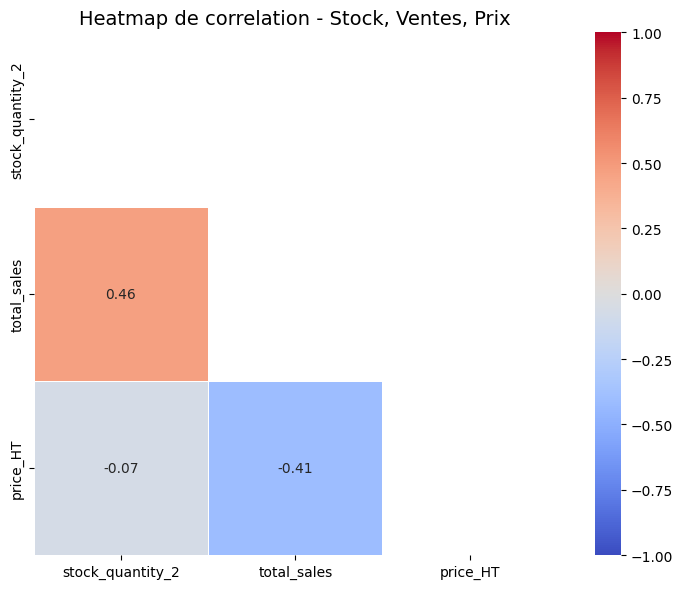

                  stock_quantity_2  total_sales  price_HT
stock_quantity_2          1.000000     0.461010 -0.065529
total_sales               0.461010     1.000000 -0.409286
price_HT                 -0.065529    -0.409286  1.000000


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_data = join[['stock_quantity_2', 'total_sales', 'price_HT']].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Heatmap de correlation - Stock, Ventes, Prix', fontsize=14)
plt.tight_layout()
plt.show()

print(corr_data)

### 5.6 - Export de la table finale

In [52]:
join.to_excel('exports/projet8_export.xlsx', index=False, sheet_name='Dataset')
print("Fichier exporte : exports/projet8_export.xlsx")

Fichier exporte : exports/projet8_export.xlsx


## Etape 6 - Conclusions et recommandations metier

### Ce que revelent les donnees

| Indicateur | Valeur | Lecture |
|---|---|---|
| Chiffre d'affaires | ~143 700 EUR | Sur ~5 750 unites vendues |
| Concentration des ventes | 80 % des ventes = ~63 % du catalogue actif | Pas de concentration extreme : le CA repose sur un large portefeuille |
| Valorisation du stock | ~548 800 EUR | Stock eleve au regard du CA : ~3,8x le chiffre d'affaires |
| Stock dormant | ~68 200 EUR (67 produits) | Produits en stock sans aucune vente |
| Prix | moyenne ~32 EUR, 19 outliers > 113 EUR | Quelques produits premium tirent la moyenne vers le haut |
| Correlations | ventes/stock : +0,46 ; prix/ventes : -0,41 | Les best-sellers sont bien reaprovisionnes ; les produits chers vendent moins en volume |

### Recommandations

1. **Destockage cible** : les produits du "Flop 20" (forte rotation de stock) et le stock dormant (en stock sans aucune vente) immobilisent de la tresorerie. Actions possibles : promotions, bundles, mise en avant sur le site.
2. **Fiabiliser le referentiel** : corriger a la source (ERP/WooCommerce) les prix negatifs, les ventes a perte et les statuts de stock incoherents, plutot qu'en aval dans l'analyse.
3. **Traquer les produits premium** : les 19 outliers de prix representent un enjeu de marge ; surveiller leur rotation pour eviter le sur-stock de references cheres.
4. **Automatiser le rapprochement** : les SKU speciaux (`bon-cadeau-25-euros`, `13127-1`) et les doublons de titres montrent que la table de liaison meriterait un identifiant unique stable.